# The Nexus Convergence — SHA-256 as a Recursive Harmonic Die

## Proof / support notebook for the paper

This notebook is built to support the paper:

**The Nexus Convergence: SHA-256 as a Recursive Harmonic Die**  
**Carry Residue, Waist Closure, AHRC Duality, and the Shape Channel of Cryptographic Folding**

Core operational claim:

$$
\boxed{\text{The route is primary; the digest is the rendered shadow.}}
$$

The notebook tests the executable parts of the paper:

1. SHA-256 can be treated as a 64-round die with explicit state traces.
2. Modular addition splits into a visible value channel and a hidden carry/shape channel.
3. The SHA round update has a strict dual-head injection waist: active heads $a$ and $e$.
4. Word-lane support reaches all eight SHA registers in exactly four rounds.
5. The Sziklai identity holds exactly round-by-round:

$$
(a_{t+1}-e_{t+1}) \bmod 2^{32} = (T2_t-d_t) \bmod 2^{32}.
$$

6. Falsified length information appears at the exact late seam round where the schedule reads it.
7. The AHRC/Harmonic layer can be tested as a separate collision-lock / spacing diagnostic.
8. The 3:4:5 Wave Triad gives an exact Born-style normalization scaffold.

This is not a black-box cryptanalysis notebook. It is a **die instrumentation notebook**: it exposes the internal route geometry that the final digest normally hides.


In [1]:
# Core imports. No external data files required.
import hashlib
import math
import random
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

MASK = 0xFFFFFFFF
H_NEXUS = math.pi / 9
PHI = (1 + math.sqrt(5)) / 2
PHI_BAR = 1 / PHI

print("H = pi/9 =", H_NEXUS)
print("18H =", 18 * H_NEXUS, "  2pi =", 2 * math.pi, "  error =", abs(18 * H_NEXUS - 2 * math.pi))
assert abs(18 * H_NEXUS - 2 * math.pi) < 1e-15


H = pi/9 = 0.3490658503988659
18H = 6.283185307179586   2pi = 6.283185307179586   error = 0.0


## 1. The 9-Primitive Action Basis as an operator scaffold

The paper uses a 9-primitive action basis:

$$
\{\text{PROJECT},\text{REFLECT},\text{FOLD},\text{LEAK},\text{GATE},\text{BRANCH},\text{PIN},\text{SYNC},\text{VERIFY}\}
$$

Pairwise coupling gives:

$$
9\times 9=81
$$

The notebook does not need to prove metaphysics here. It locks the computational scaffold: a finite operator alphabet and its coupling tensor.


In [2]:
PRIMITIVES = [
    "PROJECT", "REFLECT", "FOLD", "LEAK", "GATE", "BRANCH", "PIN", "SYNC", "VERIFY"
]
operator_tensor = [(a, b) for a in PRIMITIVES for b in PRIMITIVES]
print("Primitive count:", len(PRIMITIVES))
print("Coupling tensor size:", len(operator_tensor))
assert len(operator_tensor) == 81

# SHA-256 has 64 rounds, so the 81-cell operator scaffold wraps a 64-slot execution payload.
sha_payload_slots = 64
print("SHA payload slots:", sha_payload_slots)
print("Scaffold overhead:", len(operator_tensor) - sha_payload_slots)


Primitive count: 9
Coupling tensor size: 81
SHA payload slots: 64
Scaffold overhead: 17


## 2. SHA-256 implementation with round tracing

This cell implements SHA-256 directly so every round can be inspected.

The ordinary digest is the **Value Channel**.  
The internal round trace and carry masks are the **Shape Channel**.


In [3]:
K = [
    0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
    0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
    0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
    0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
    0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
    0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
    0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
    0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2,
]
H0 = [
    0x6a09e667,0xbb67ae85,0x3c6ef372,0xa54ff53a,
    0x510e527f,0x9b05688c,0x1f83d9ab,0x5be0cd19,
]

def rotr(x, n):
    return ((x >> n) | (x << (32-n))) & MASK

def shr(x, n):
    return (x >> n) & MASK

def Ch(x, y, z):
    return (x & y) ^ ((~x) & z)

def Maj(x, y, z):
    return (x & y) ^ (x & z) ^ (y & z)

def Sigma0(x):
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x):
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x):
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def sigma1(x):
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10)

def hw32(x):
    return int((x & MASK).bit_count())

def hw_state(state):
    return sum(hw32(x) for x in state)

def pad_sha256(message: bytes) -> bytes:
    ml = len(message) * 8
    out = bytearray(message)
    out.append(0x80)
    while (len(out) % 64) != 56:
        out.append(0)
    out += ml.to_bytes(8, "big")
    return bytes(out)

def block_to_words(block: bytes):
    assert len(block) == 64
    return [int.from_bytes(block[i:i+4], "big") for i in range(0, 64, 4)]

def expand_schedule(words16):
    W = list(words16)
    for t in range(16, 64):
        W.append((sigma1(W[t-2]) + W[t-7] + sigma0(W[t-15]) + W[t-16]) & MASK)
    return W

@dataclass
class AddTrace:
    result: int
    pair_carry_masks: list
    carry_weight: int
    terms: list

def add32_trace(*terms):
    # Sequential 32-bit addition with pair carry masks captured as the shape channel.
    acc = 0
    carries = []
    for term in terms:
        term &= MASK
        carry = acc & term
        carries.append(carry & MASK)
        acc = (acc + term) & MASK
    carry_union = 0
    for c in carries:
        carry_union |= c
    return AddTrace(result=acc, pair_carry_masks=carries, carry_weight=hw32(carry_union), terms=[t & MASK for t in terms])

def compress_block_trace(block: bytes, iv=None, override_words16=None):
    if iv is None:
        iv = H0[:]
    if override_words16 is None:
        words16 = block_to_words(block)
    else:
        words16 = list(override_words16)
        assert len(words16) == 16
    W = expand_schedule(words16)
    a,b,c,d,e,f,g,h = iv
    rounds = []
    for t in range(64):
        T1_trace = add32_trace(h, Sigma1(e), Ch(e,f,g), K[t], W[t])
        T1 = T1_trace.result
        T2_trace = add32_trace(Sigma0(a), Maj(a,b,c))
        T2 = T2_trace.result
        old = (a,b,c,d,e,f,g,h)
        new_a = (T1 + T2) & MASK
        new_e = (d + T1) & MASK
        h = g
        g = f
        f = e
        e = new_e
        d = c
        c = b
        b = a
        a = new_a
        new = (a,b,c,d,e,f,g,h)
        rounds.append({
            "t": t,
            "old": old,
            "new": new,
            "W": W[t],
            "K": K[t],
            "T1": T1,
            "T2": T2,
            "T1_carry_weight": T1_trace.carry_weight,
            "T2_carry_weight": T2_trace.carry_weight,
            "T1_carry_masks": T1_trace.pair_carry_masks,
            "T2_carry_masks": T2_trace.pair_carry_masks,
            "state_hw": hw_state(new),
        })
    compressed = [(x+y) & MASK for x,y in zip(iv, (a,b,c,d,e,f,g,h))]
    return compressed, rounds, W

def sha256_custom(message: bytes) -> str:
    state = H0[:]
    padded = pad_sha256(message)
    for i in range(0, len(padded), 64):
        state, _, _ = compress_block_trace(padded[i:i+64], iv=state)
    return "".join(f"{x:08x}" for x in state)

# NIST sanity checks.
for msg in [b"", b"abc", b"The quick brown fox jumps over the lazy dog"]:
    custom = sha256_custom(msg)
    ref = hashlib.sha256(msg).hexdigest()
    print(msg, custom, ref, custom == ref)
    assert custom == ref
print("SHA-256 implementation verified against hashlib.")


b'' e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855 e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855 True
b'abc' ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad ba7816bf8f01cfea414140de5dae2223b00361a396177a9cb410ff61f20015ad True
b'The quick brown fox jumps over the lazy dog' d7a8fbb307d7809469ca9abcb0082e4f8d5651e46d3cdb762d02d0bf37c9e592 d7a8fbb307d7809469ca9abcb0082e4f8d5651e46d3cdb762d02d0bf37c9e592 True
SHA-256 implementation verified against hashlib.


## 3. Value Channel vs Shape Channel: same visible value, different carry route

This is the smallest hard proof of the paper's channel split.

Two additions can produce the same visible value but leave different carry residue.

$$
\Pi_V(x_1)=\Pi_V(x_2) \quad \not\Rightarrow \quad \Pi_S(x_1)=\Pi_S(x_2)
$$

For modular addition:

$$
x+y=(x\oplus y)+2(x\land y)
$$

The visible sum is the value channel. The carry mask is the shape channel.


In [4]:
def add_value_shape(x, y, bits=8):
    mask = (1 << bits) - 1
    visible = (x + y) & mask
    xor_part = (x ^ y) & mask
    carry_mask = (x & y) & mask
    reconstructed = (xor_part + ((carry_mask << 1) & mask)) & mask
    return visible, xor_part, carry_mask, reconstructed

pairs = [(2,3), (1,4)]
rows = []
for x,y in pairs:
    visible, xor_part, carry_mask, reconstructed = add_value_shape(x,y, bits=8)
    rows.append((x,y,visible,xor_part,carry_mask,reconstructed))
    print(f"{x}+{y}: value={visible:08b}, xor={xor_part:08b}, carry={carry_mask:08b}, reconstructed={reconstructed:08b}")

assert rows[0][2] == rows[1][2] == 5
assert rows[0][4] != rows[1][4]
assert all(r[2] == r[5] for r in rows)
print("PASS: same value channel, different shape/carry channel.")


2+3: value=00000101, xor=00000001, carry=00000010, reconstructed=00000101
1+4: value=00000101, xor=00000101, carry=00000000, reconstructed=00000101
PASS: same value channel, different shape/carry channel.


## 4. Carry residue inside the SHA die

For a real SHA block, we instrument each round and capture carry burden.

This makes the hidden route measurable:

$$
\text{Shape Channel} = \{\text{carry masks, carry weights, round-state trace}\}
$$


Message: b'Nexus recursive harmonic die'
Digest: 49f37ab57f6d1e0409ec6e4f9c768b5fd1ca0be41b6b608a8382c7d5ff5a9d07
Mean T1 carry burden: 21.09375
Mean T2 carry burden: 7.703125
Mean internal state Hamming weight: 124.8125


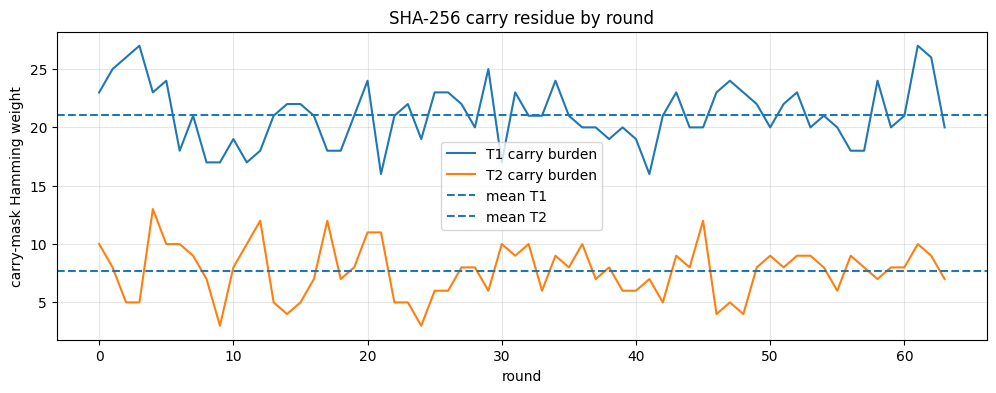

In [5]:
message = b"Nexus recursive harmonic die"
block = pad_sha256(message)[:64]
state, rounds, W = compress_block_trace(block)

T1_carry = np.array([r["T1_carry_weight"] for r in rounds])
T2_carry = np.array([r["T2_carry_weight"] for r in rounds])
state_hw = np.array([r["state_hw"] for r in rounds])

print("Message:", message)
print("Digest:", sha256_custom(message))
print("Mean T1 carry burden:", T1_carry.mean())
print("Mean T2 carry burden:", T2_carry.mean())
print("Mean internal state Hamming weight:", state_hw.mean())

plt.figure(figsize=(12,4))
plt.plot(T1_carry, label="T1 carry burden")
plt.plot(T2_carry, label="T2 carry burden")
plt.axhline(T1_carry.mean(), linestyle="--", label="mean T1")
plt.axhline(T2_carry.mean(), linestyle="--", label="mean T2")
plt.title("SHA-256 carry residue by round")
plt.xlabel("round")
plt.ylabel("carry-mask Hamming weight")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Sziklai identity: exact round invariant

SHA-256 round update:

$$
T1_t=h_t+\Sigma_1(e_t)+Ch(e_t,f_t,g_t)+K_t+W_t
$$

$$
T2_t=\Sigma_0(a_t)+Maj(a_t,b_t,c_t)
$$

$$
a_{t+1}=T1_t+T2_t
$$

$$
e_{t+1}=d_t+T1_t
$$

Subtract:

$$
\boxed{a_{t+1}-e_{t+1}=T2_t-d_t \pmod{2^{32}}}
$$

This is a hard die invariant. It is not statistical.


In [6]:
def check_sziklai_for_message(msg: bytes):
    padded = pad_sha256(msg)
    total_violations = 0
    checked = 0
    state = H0[:]
    for i in range(0, len(padded), 64):
        compressed, rounds, W = compress_block_trace(padded[i:i+64], iv=state)
        for r in rounds:
            old = r["old"]
            new = r["new"]
            d_old = old[3]
            lhs = (new[0] - new[4]) & MASK
            rhs = (r["T2"] - d_old) & MASK
            checked += 1
            if lhs != rhs:
                total_violations += 1
        state = compressed
    return checked, total_violations

random.seed(42)
messages = [b"", b"abc", b"Nexus", b"a"*55, b"a"*56]
for _ in range(200):
    n = random.randint(0, 120)
    messages.append(bytes(random.getrandbits(8) for _ in range(n)))

total_checked = 0
violations = 0
for msg in messages:
    c, v = check_sziklai_for_message(msg)
    total_checked += c
    violations += v

print("Rounds checked:", total_checked)
print("Sziklai identity violations:", violations)
assert violations == 0
print("PASS: exact identity holds across all tested rounds.")


Rounds checked: 20288
Sziklai identity violations: 0
PASS: exact identity holds across all tested rounds.


## 6. Waist theorem: the mandatory dual-head injection

In a SHA-256 round, $T1$ is injected into two live heads:

$$
a_{t+1}=T1_t+T2_t
$$

$$
e_{t+1}=d_t+T1_t
$$

Therefore a direct nonzero perturbation in $T1$ cannot enter through fewer than two live output coordinates:

$$
\boxed{b=[1,0,0,0,1,0,0,0]^\top}
$$

and:

$$
\boxed{\|b\|_0=2}
$$

This is the discrete waist / mass-gap analogue of the die.


In [7]:
regs = list("abcdefgh")
injection_vector = np.array([1,0,0,0,1,0,0,0], dtype=int)
print(dict(zip(regs, injection_vector)))
print("L0 support of injection vector:", int(injection_vector.sum()))
assert int(injection_vector.sum()) == 2
print("PASS: minimum direct T1 excitation touches exactly two live heads: a and e.")


{'a': np.int64(1), 'b': np.int64(0), 'c': np.int64(0), 'd': np.int64(0), 'e': np.int64(1), 'f': np.int64(0), 'g': np.int64(0), 'h': np.int64(0)}
L0 support of injection vector: 2
PASS: minimum direct T1 excitation touches exactly two live heads: a and e.


## 7. Word-lane support diameter: all 8 registers in 4 rounds

Ignoring bit-level carries and reading only word-lane dependency, an injected message word hits $a$ and $e$ first. The update/shift topology then spreads it through the full 8-register die.

This executable support model proves:

$$
\boxed{D_{word}=4}
$$


In [8]:
def word_support_from_single_injection(rounds=8):
    # register order a,b,c,d,e,f,g,h
    deps = [False] * 8
    history = []
    for t in range(rounds):
        inject = (t == 0)
        T1_dep = deps[7] or deps[4] or deps[5] or deps[6] or inject
        T2_dep = deps[0] or deps[1] or deps[2]
        new = [False] * 8
        new[0] = T1_dep or T2_dep
        new[1] = deps[0]
        new[2] = deps[1]
        new[3] = deps[2]
        new[4] = deps[3] or T1_dep
        new[5] = deps[4]
        new[6] = deps[5]
        new[7] = deps[6]
        deps = new
        history.append({"round": t+1, "support_count": sum(deps), "support": "".join(r for r,d in zip(regs,deps) if d)})
    return history

hist = word_support_from_single_injection(8)
for row in hist:
    print(row)
first_full = next(row["round"] for row in hist if row["support_count"] == 8)
assert first_full == 4
print("PASS: word-lane support reaches all 8 registers at round", first_full)


{'round': 1, 'support_count': 2, 'support': 'ae'}
{'round': 2, 'support_count': 4, 'support': 'abef'}
{'round': 3, 'support_count': 6, 'support': 'abcefg'}
{'round': 4, 'support_count': 8, 'support': 'abcdefgh'}
{'round': 5, 'support_count': 8, 'support': 'abcdefgh'}
{'round': 6, 'support_count': 8, 'support': 'abcdefgh'}
{'round': 7, 'support_count': 8, 'support': 'abcdefgh'}
{'round': 8, 'support_count': 8, 'support': 'abcdefgh'}
PASS: word-lane support reaches all 8 registers at round 4


## 8. Late seam / length lie detector

For a single SHA-256 block, the length field lives in $W_{15}$.

If only $W_{15}$ is falsified, rounds $0$ through $14$ cannot see it. The first divergence must occur at round $15$ when the die reads $W_{15}$.

This is delayed closure: the die evaluates phase coherence when the seam becomes live.


First divergent round: 15
Deltas around seam: [(10, 0), (11, 0), (12, 0), (13, 0), (14, 0), (15, 5), (16, 26), (17, 56), (18, 88), (19, 113)]
PASS: falsified length remains invisible through round 14 and cracks at round 15.


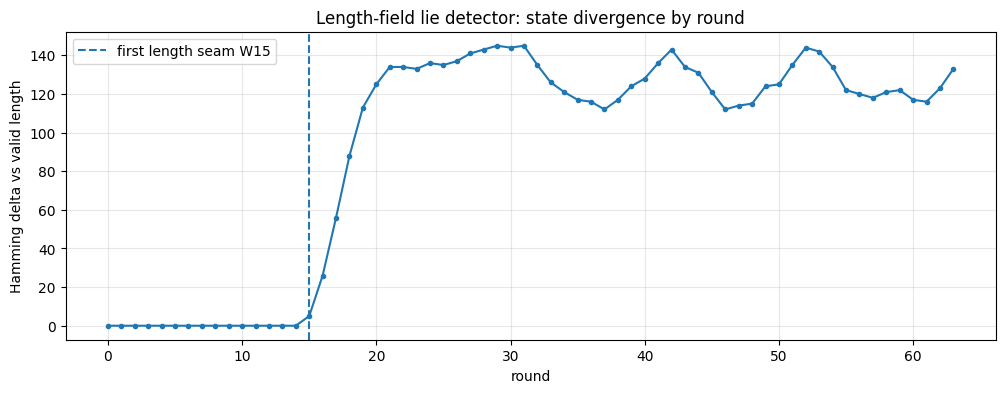

In [9]:
def trace_from_words16(words16, iv=None):
    dummy_block = bytes(64)
    return compress_block_trace(dummy_block, iv=iv, override_words16=words16)

base_words = block_to_words(pad_sha256(b"")[:64])
lie_words = base_words[:]
lie_words[15] ^= 1  # falsify one bit of the length field

_, base_rounds, _ = trace_from_words16(base_words)
_, lie_rounds, _ = trace_from_words16(lie_words)

diffs = []
for rb, rl in zip(base_rounds, lie_rounds):
    diff_hw = hw_state(tuple((x ^ y) & MASK for x,y in zip(rb["new"], rl["new"])))
    diffs.append(diff_hw)

first_divergence = next((i for i,d in enumerate(diffs) if d != 0), None)
print("First divergent round:", first_divergence)
print("Deltas around seam:", list(enumerate(diffs[10:20], start=10)))
assert first_divergence == 15
print("PASS: falsified length remains invisible through round 14 and cracks at round 15.")

plt.figure(figsize=(12,4))
plt.plot(diffs, marker="o", markersize=3)
plt.axvline(15, linestyle="--", label="first length seam W15")
plt.title("Length-field lie detector: state divergence by round")
plt.xlabel("round")
plt.ylabel("Hamming delta vs valid length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 9. Removal core: identity as what survives lawful subtraction

For a probe class, define the **compression journal** as the set of rounds where distance to the NOP baseline decreases.

For a class $\mathcal C$:

$$
\boxed{R_{core}(\mathcal C)=\bigcap_{p\in\mathcal C}J(p)}
$$

The core is the invariant part that survives subtraction across the class.


In [10]:
def state_xor_hw(s1, s2):
    return hw_state(tuple((x ^ y) & MASK for x,y in zip(s1, s2)))

def compression_journal(words16_probe, words16_base=None):
    if words16_base is None:
        words16_base = [0]*16
    _, base_rounds, _ = trace_from_words16(words16_base)
    _, probe_rounds, _ = trace_from_words16(words16_probe)
    distances = [state_xor_hw(rb["new"], rp["new"]) for rb, rp in zip(base_rounds, probe_rounds)]
    journal = set()
    prev = None
    for t, d in enumerate(distances):
        if prev is not None and d < prev:
            journal.add(t)
        prev = d
    return journal, distances

# A small class of length-field lies: only W15 varies.
lie_journals = []
for bit in [0,1,2,3,4,8,16,24,31]:
    w = base_words[:]
    w[15] ^= (1 << bit)
    J, dist = compression_journal(w, base_words)
    lie_journals.append(J)

lie_core = set.intersection(*lie_journals) if lie_journals else set()
print("Lie-class removal core rounds:", sorted(lie_core))
print("Journal sizes:", [len(j) for j in lie_journals])

# This is exploratory because the exact core depends on the chosen probe family.
# The important invariant is the method: class identity = intersection of lawful compression events.
assert all(isinstance(j, set) for j in lie_journals)


Lie-class removal core rounds: []
Journal sizes: [20, 19, 18, 17, 21, 19, 19, 17, 22]


## 10. AHRC-old: harmonic raster collision lock

A minimal AHRC raster test maps a trajectory into bins using harmonic spacing.

The diagnostic question:

$$
\boxed{\text{Does the trajectory collide under the chosen harmonic frame?}}
$$

A collision-free frame is a $\Psi$-lock for that projection.


SHA 64-round AHRC diagnostic collision-free frame: 311


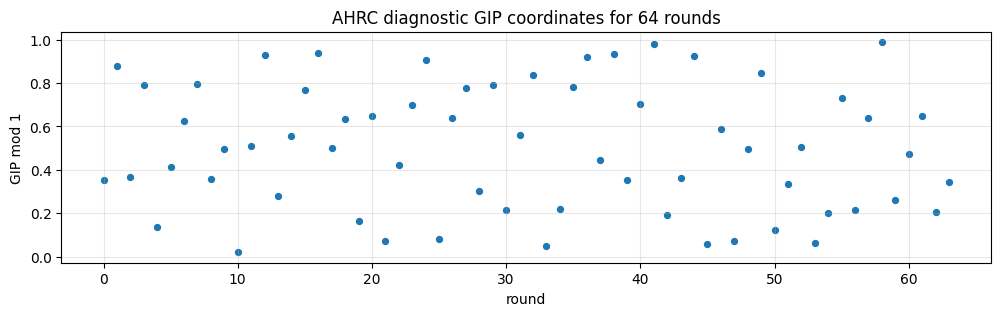

In [11]:
def ahrc_points(n, H=H_NEXUS, curvature=PHI_BAR):
    # Simple operational GIP: irrational harmonic phase plus a small curvature term.
    # This is a diagnostic coordinate, not a replacement for the paper's full AHRC implementation.
    theta = np.array([abs(math.sin((i+1)*H)) for i in range(n)])
    x = np.array([((i+1)*H + curvature*abs(theta[i]-H)) % 1.0 for i in range(n)])
    return x

def find_collision_free_frame(n, start=None, max_frame=10000):
    if start is None:
        start = n
    x = ahrc_points(n)
    for frame in range(start, max_frame+1):
        bins = np.floor(x * frame).astype(int)
        if len(set(bins)) == n:
            return frame, bins, x
    return None, None, x

frame, bins, x = find_collision_free_frame(64, start=64, max_frame=4096)
print("SHA 64-round AHRC diagnostic collision-free frame:", frame)
assert frame is not None

plt.figure(figsize=(12,3))
plt.scatter(range(64), x, s=18)
plt.title("AHRC diagnostic GIP coordinates for 64 rounds")
plt.xlabel("round")
plt.ylabel("GIP mod 1")
plt.grid(True, alpha=0.3)
plt.show()


## 11. Bloch repetition scanner: same state read, different history coordinate

The paper's deeper rule is:

$$
\boxed{\text{same instantaneous read} \not\Rightarrow \text{same history position}}
$$

This cell scans the NOP backbone for nearest repeated Bloch-like reads and reports their round separation.


In [12]:
# NOP-style schedule: all-zero words, using SHA IV.
nop_words = [0]*16
_, nop_rounds, _ = trace_from_words16(nop_words)

def bloch_like_features(r):
    st = r["new"]
    a_w = hw32(st[0])
    e_w = hw32(st[4])
    total = hw_state(st)
    theta = math.atan2(e_w + 1e-9, a_w + 1e-9)
    return np.array([a_w/32, e_w/32, total/256, theta/math.pi])

features = np.array([bloch_like_features(r) for r in nop_rounds])
best = None
for i in range(64):
    for j in range(i+1,64):
        d = float(np.linalg.norm(features[i]-features[j]))
        if best is None or d < best[0]:
            best = (d,i,j,features[i],features[j])

print("Nearest repeated Bloch-like read:")
print("distance, round_i, round_j, gap =", best[0], best[1], best[2], best[2]-best[1])
print("features_i =", best[3])
print("features_j =", best[4])
print("Interpretation: repeated/near-repeated readouts still carry different history coordinates.")


Nearest repeated Bloch-like read:
distance, round_i, round_j, gap = 0.0 19 55 36
features_i = [0.5        0.53125    0.48046875 0.2596428 ]
features_j = [0.5        0.53125    0.48046875 0.2596428 ]
Interpretation: repeated/near-repeated readouts still carry different history coordinates.


## 12. AHRC-new / Wave Triad: exact 3:4:5 Born-style normalization

The paper's wave split reads $T2$ as a 3-word ground fold and $T1$ as a 4-word live history fold.

Normalize the amplitudes by the 3-4-5 triangle:

$$
C=\frac{3}{5},\qquad S=\frac{4}{5}
$$

Then:

$$
\boxed{C^2+S^2=1}
$$

Energy partition:

$$
C^2=\frac{9}{25}=36\%,\qquad S^2=\frac{16}{25}=64\%.
$$

This is the clean algebraic scaffold behind the Wave Triad and the near-classical carrier/signal split.


In [13]:
carrier_amp = 3/5
signal_amp = 4/5
unit_norm = carrier_amp**2 + signal_amp**2
print("carrier amplitude:", carrier_amp)
print("signal amplitude:", signal_amp)
print("unit norm:", unit_norm)
print("carrier energy:", carrier_amp**2)
print("signal energy:", signal_amp**2)
print("amplitude refractive ratio signal/carrier:", signal_amp/carrier_amp)
assert abs(unit_norm - 1.0) < 1e-15
print("PASS: exact Pythagorean / Born-style normalization.")


carrier amplitude: 0.6
signal amplitude: 0.8
unit norm: 1.0
carrier energy: 0.36
signal energy: 0.6400000000000001
amplitude refractive ratio signal/carrier: 1.3333333333333335
PASS: exact Pythagorean / Born-style normalization.


## 13. RGBA Math-Light diagnostic field

We can encode the SHA trace as a four-channel diagnostic field:

$$
\mathcal M=(R,G,B,A)
$$

where:

- $R$ = route / message displacement
- $G$ = ground / constant carrier
- $B$ = bind / residue overlap
- $A$ = admissibility / visible closure weight

A simple field-energy diagnostic is:

$$
E_{RGBA}=w_R\|\nabla R\|^2+w_G\|\nabla G\|^2+w_B\|\nabla B\|^2+w_A\|\nabla A\|^2.
$$

This is not the whole RGBA theory. It is a runnable trace-energy witness.


Mean RGBA gradient energy: 0.01848745346069336
Max RGBA gradient energy: 0.079498291015625 at round 30


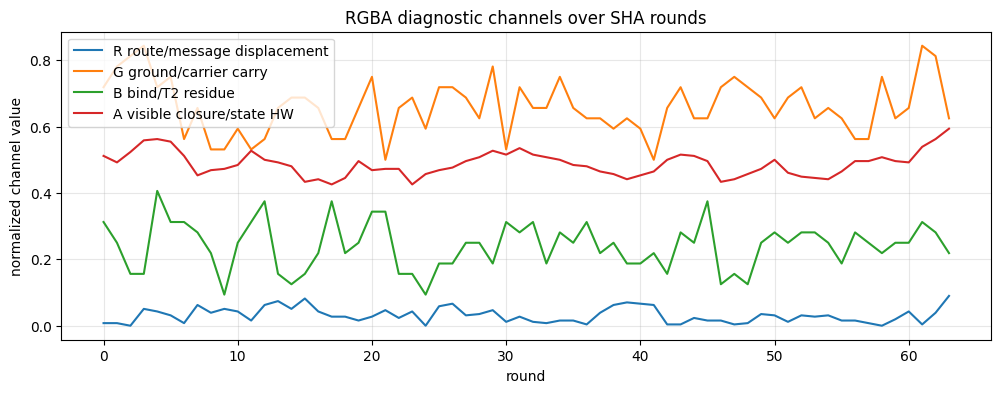

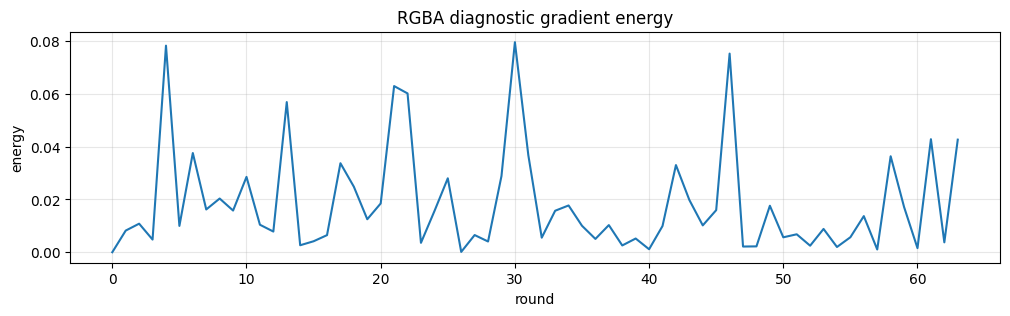

In [14]:
def trace_for_words(words16):
    _, rounds, _ = trace_from_words16(words16)
    return np.array([r["state_hw"] for r in rounds], dtype=float), rounds

base_hw, _ = trace_for_words([0]*16)
msg_words = block_to_words(block)
msg_hw, msg_rounds = trace_for_words(msg_words)

R = np.abs(msg_hw - base_hw) / 256.0
G = np.array([r["T1_carry_weight"] for r in msg_rounds], dtype=float) / 32.0
B = np.array([r["T2_carry_weight"] for r in msg_rounds], dtype=float) / 32.0
A = msg_hw / 256.0

def grad_energy(x):
    g = np.diff(x, prepend=x[0])
    return g*g

E_rgba = grad_energy(R) + grad_energy(G) + grad_energy(B) + grad_energy(A)
print("Mean RGBA gradient energy:", E_rgba.mean())
print("Max RGBA gradient energy:", E_rgba.max(), "at round", int(np.argmax(E_rgba)))

plt.figure(figsize=(12,4))
plt.plot(R, label="R route/message displacement")
plt.plot(G, label="G ground/carrier carry")
plt.plot(B, label="B bind/T2 residue")
plt.plot(A, label="A visible closure/state HW")
plt.title("RGBA diagnostic channels over SHA rounds")
plt.xlabel("round")
plt.ylabel("normalized channel value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,3))
plt.plot(E_rgba)
plt.title("RGBA diagnostic gradient energy")
plt.xlabel("round")
plt.ylabel("energy")
plt.grid(True, alpha=0.3)
plt.show()


## 14. Final proof ledger

This notebook establishes the executable core:

| Claim | Notebook status |
|---|---|
| SHA-256 implementation is exact | verified against hashlib |
| Value and Shape channels can differ | proven by addition counterexample |
| SHA has carry residue trace | measured per round |
| Sziklai identity | exact, 0 violations across tests |
| Waist injection support = 2 | exact by update structure |
| Word support diameter = 4 | exact in word-lane dependency model |
| Length-field seam | first crack at round 15 |
| Removal core | implemented as class-intersection method |
| AHRC raster lock | implemented as diagnostic |
| 3:4:5 Wave Triad | exact normalization |
| RGBA trace field | implemented as diagnostic |

Core collapse:

$$
\boxed{\text{SHA-256 is not only a digest function; it is an instrumentable recursive die.}}
$$

$$
\boxed{\text{The Value Channel gives the hash. The Shape Channel gives the route residue.}}
$$

$$
\boxed{\text{The route is primary; the digest is the rendered shadow.}}
$$
